<a href="https://colab.research.google.com/github/Lehuutien2908/DataMining/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dự đoán nguy cơ mắc bệnh tim

Notebook này trình bày toàn bộ quy trình xử lý dữ liệu, xây dựng và so sánh các mô hình (MLP, Random Forest, XGBoost, SVM) nhằm dự đoán khả năng mắc bệnh tim dựa trên các chỉ số lâm sàng.


## Quy trình tổng quát
- Khảo sát dữ liệu, kiểm tra thiếu và ngoại lệ
- Làm sạch, chuẩn hóa và chọn đặc trưng
- Chia dữ liệu train/test (stratify theo nhãn)
- Huấn luyện MLP (Keras Sequential) và các mô hình so sánh: Random Forest, XGBoost, SVM
- Đánh giá Accuracy, Precision, Recall, F1, Specificity, AUC-ROC


(1025, 14)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

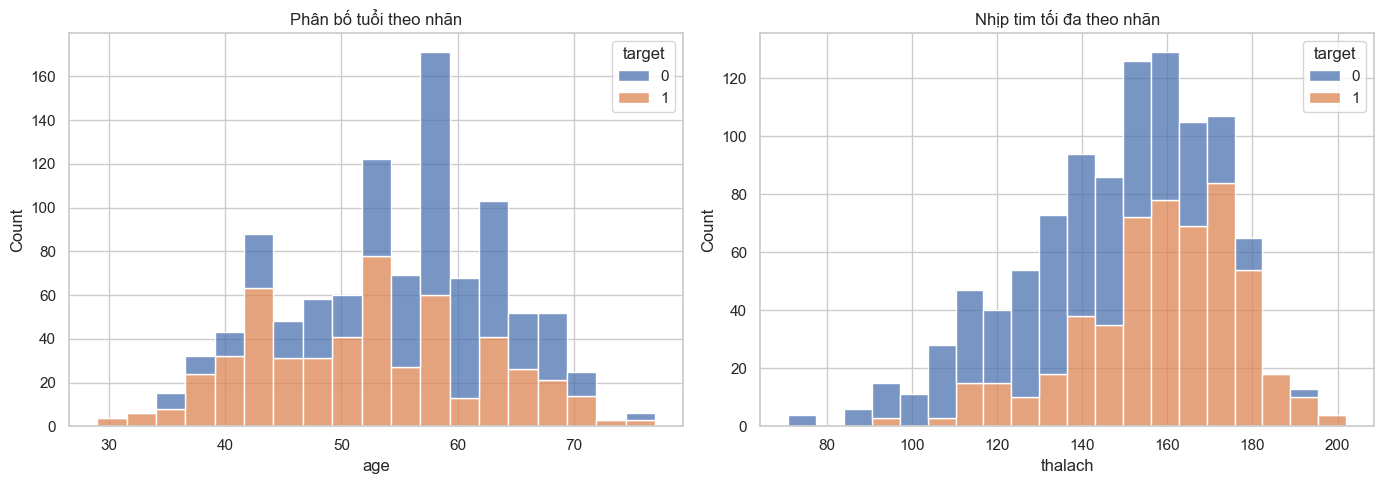

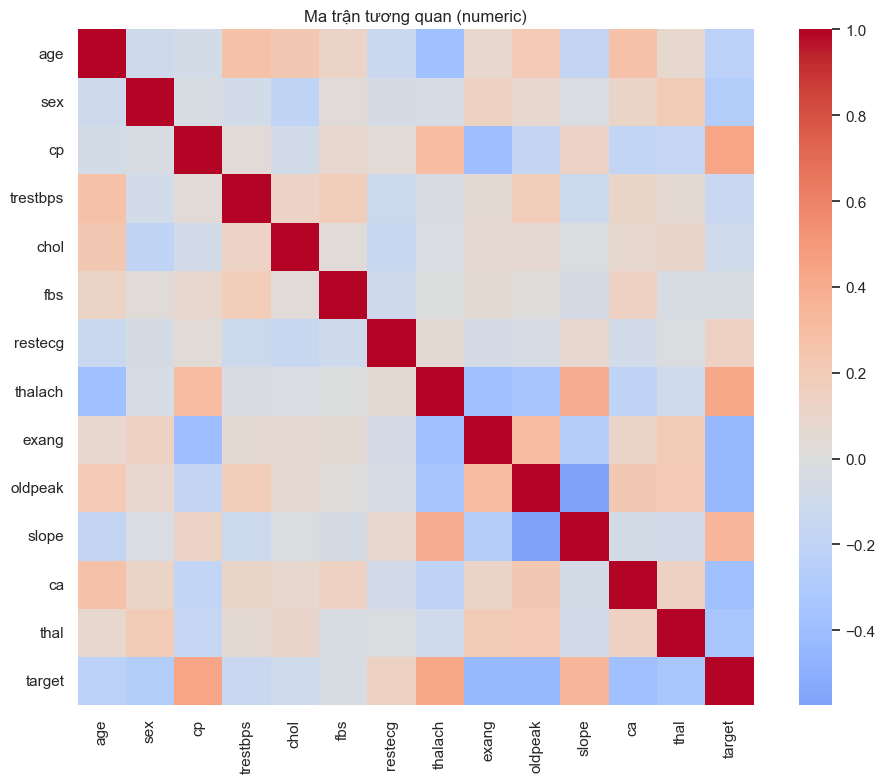

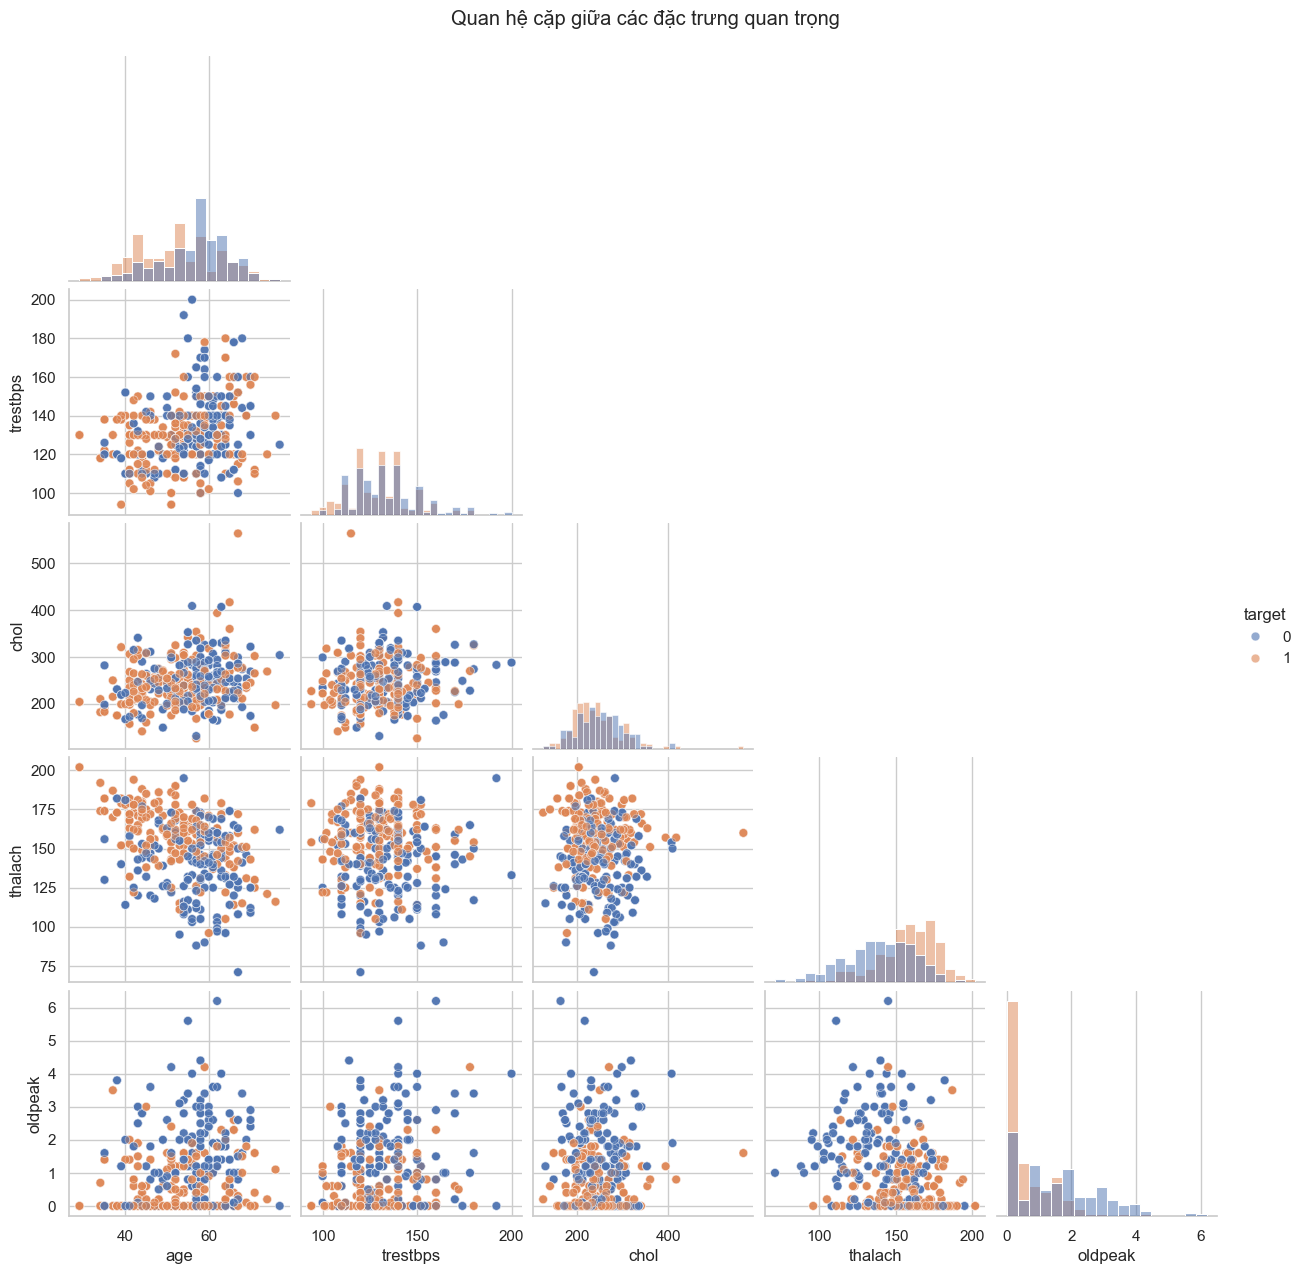

Train: (717, 13), Test: (308, 13)
Đặc trưng được giữ lại: ['age', 'cp', 'trestbps', 'chol', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


,model,accuracy,precision,recall,f1,specificity,auc
0,MLP (Keras),0.974026,0.980769,0.968354,0.974522,0.98,0.991646


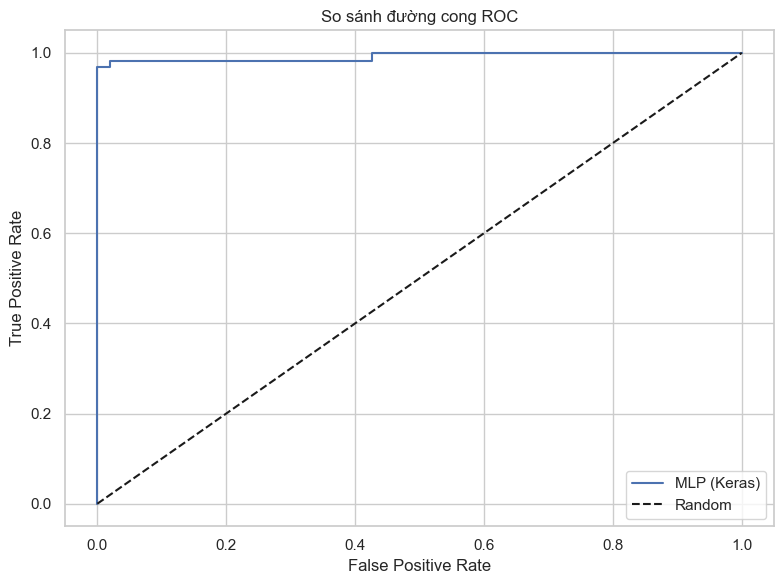

,model,accuracy,precision,recall,f1,specificity,auc
1,XGBoost,0.970779,0.968553,0.974684,0.971609,0.966667,0.992447
0,MLP (Keras),0.974026,0.980769,0.968354,0.974522,0.980000,0.991646


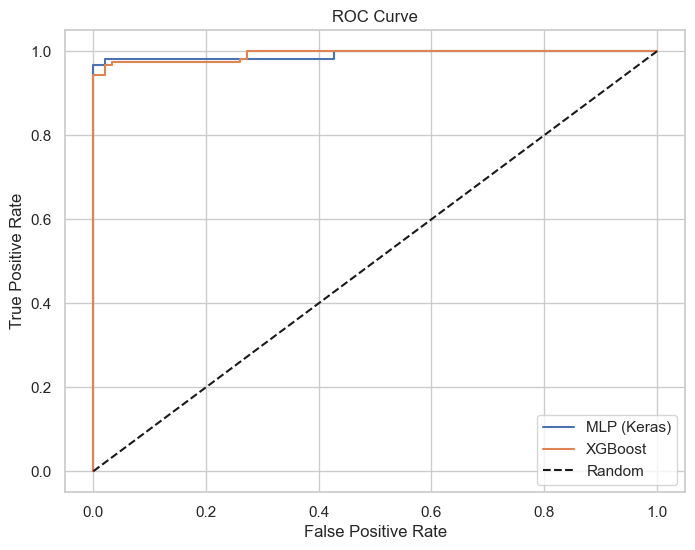

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import xgboost as xgb
import tensorflow as tf
from tensorflow import keras

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

DATA_PATH = Path("heart.csv")
raw_df = pd.read_csv(DATA_PATH)
raw_df.head()

display(raw_df.shape)
display(raw_df.describe(include="all"))
display(raw_df.isna().sum())


# Khảo sát nhanh phân phối và tương quan các đặc trưng chính
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=raw_df, x="age", hue="target", multiple="stack", ax=axes[0])
axes[0].set_title("Phân bố tuổi theo nhãn")
sns.histplot(data=raw_df, x="thalach", hue="target", multiple="stack", ax=axes[1])
axes[1].set_title("Nhịp tim tối đa theo nhãn")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
corr = raw_df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Ma trận tương quan (numeric)")
plt.tight_layout()
plt.show()

pairplot_features = ["age", "trestbps", "chol", "thalach", "oldpeak", "target"]
sns.pairplot(
    raw_df[pairplot_features],
    hue="target",
    diag_kind="hist",
    corner=True,
    plot_kws={"alpha": 0.6, "s": 40}
)
plt.suptitle("Quan hệ cặp giữa các đặc trưng quan trọng", y=1.02)
plt.show()

X = raw_df.drop(columns="target")
y = raw_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")



scaler = StandardScaler()
selector = SelectKBest(score_func=mutual_info_classif, k=min(10, X_train.shape[1]))

# Chuẩn hóa
X_train_proc = scaler.fit_transform(X_train, y_train)
X_test_proc = scaler.transform(X_test)

# Chọn đặc trưng
selector.fit(X_train_proc, y_train)

# Lấy mask đặc trưng được chọn
selected_mask = selector.get_support()
selected_features = X_train.columns[selected_mask]
print("Đặc trưng được giữ lại:", list(selected_features))


def evaluate_model(name: str, y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> dict:
    """Trả về bộ metric cho từng mô hình."""
    y_pred = (y_prob >= threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp)
    return {
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "specificity": specificity,
        "auc": auc
    }

results = []
roc_curves = {}


tf.keras.utils.set_random_seed(RANDOM_STATE)

mlp_model = keras.Sequential([
    keras.layers.Input(shape=(X_train_proc.shape[1],)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation="sigmoid")
])

mlp_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

history = mlp_model.fit(
    X_train_proc,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

mlp_probs = mlp_model.predict(X_test_proc).ravel()
results.append(evaluate_model("MLP (Keras)", y_test.values, mlp_probs))
fpr, tpr, _ = roc_curve(y_test, mlp_probs)
roc_curves["MLP (Keras)"] = (fpr, tpr)


results_df = pd.DataFrame(results).sort_values(by="auc", ascending=False)
display(results_df)



plt.figure(figsize=(8, 6))
for name, (fpr, tpr) in roc_curves.items():
    plt.plot(fpr, tpr, label=f"{name}")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("So sánh đường cong ROC")
plt.legend()
plt.tight_layout()
plt.show()


xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=RANDOM_STATE
)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_proc, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
)

xgb_model.fit(
    X_tr,
    y_tr,
    eval_set=[(X_val, y_val)],
    verbose=0
)

xgb_probs = xgb_model.predict_proba(X_test_proc)[:, 1]
results.append(evaluate_model("XGBoost", y_test.values, xgb_probs))
fpr, tpr, _ = roc_curve(y_test, xgb_probs)
roc_curves["XGBoost"] = (fpr, tpr)

results_df = pd.DataFrame(results).sort_values(by="auc", ascending=False)
display(results_df)

plt.figure(figsize=(8, 6))
for name, (fpr, tpr) in roc_curves.items():
    plt.plot(fpr, tpr, label=f"{name}")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Association Rules với Apriori Algorithm

Phân tích luật kết hợp để tìm các mẫu và mối quan hệ giữa các đặc trưng trong dữ liệu bệnh tim.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import xgboost as xgb
import tensorflow as tf
from tensorflow import keras

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

DATA_PATH = Path("heart.csv")
raw_df = pd.read_csv(DATA_PATH)
raw_df.head()

display(raw_df.shape)
display(raw_df.describe(include="all"))
display(raw_df.isna().sum())


# Khảo sát nhanh phân phối và tương quan các đặc trưng chính
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=raw_df, x="age", hue="target", multiple="stack", ax=axes[0])
axes[0].set_title("Phân bố tuổi theo nhãn")
sns.histplot(data=raw_df, x="thalach", hue="target", multiple="stack", ax=axes[1])
axes[1].set_title("Nhịp tim tối đa theo nhãn")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
corr = raw_df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Ma trận tương quan (numeric)")
plt.tight_layout()
plt.show()

pairplot_features = ["age", "trestbps", "chol", "thalach", "oldpeak", "target"]
sns.pairplot(
    raw_df[pairplot_features],
    hue="target",
    diag_kind="hist",
    corner=True,
    plot_kws={"alpha": 0.6, "s": 40}
)
plt.suptitle("Quan hệ cặp giữa các đặc trưng quan trọng", y=1.02)
plt.show()

X = raw_df.drop(columns="target")
y = raw_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")



scaler = StandardScaler()
selector = SelectKBest(score_func=mutual_info_classif, k=min(10, X_train.shape[1]))

# Chuẩn hóa
X_train_proc = scaler.fit_transform(X_train, y_train)
X_test_proc = scaler.transform(X_test)

# Chọn đặc trưng
selector.fit(X_train_proc, y_train)

# Lấy mask đặc trưng được chọn
selected_mask = selector.get_support()
selected_features = X_train.columns[selected_mask]
print("Đặc trưng được giữ lại:", list(selected_features))


def evaluate_model(name: str, y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> dict:
    """Trả về bộ metric cho từng mô hình."""
    y_pred = (y_prob >= threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp)
    return {
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "specificity": specificity,
        "auc": auc
    }

results = []
roc_curves = {}


tf.keras.utils.set_random_seed(RANDOM_STATE)

mlp_model = keras.Sequential([
    keras.layers.Input(shape=(X_train_proc.shape[1],)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation="sigmoid")
])

mlp_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

history = mlp_model.fit(
    X_train_proc,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

mlp_probs = mlp_model.predict(X_test_proc).ravel()
results.append(evaluate_model("MLP (Keras)", y_test.values, mlp_probs))
fpr, tpr, _ = roc_curve(y_test, mlp_probs)
roc_curves["MLP (Keras)"] = (fpr, tpr)


results_df = pd.DataFrame(results).sort_values(by="auc", ascending=False)
display(results_df)



plt.figure(figsize=(8, 6))
for name, (fpr, tpr) in roc_curves.items():
    plt.plot(fpr, tpr, label=f"{name}")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("So sánh đường cong ROC")
plt.legend()
plt.tight_layout()
plt.show()


xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=RANDOM_STATE
)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_proc, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
)

xgb_model.fit(
    X_tr,
    y_tr,
    eval_set=[(X_val, y_val)],
    verbose=0
)

xgb_probs = xgb_model.predict_proba(X_test_proc)[:, 1]
results.append(evaluate_model("XGBoost", y_test.values, xgb_probs))
fpr, tpr, _ = roc_curve(y_test, xgb_probs)
roc_curves["XGBoost"] = (fpr, tpr)

results_df = pd.DataFrame(results).sort_values(by="auc", ascending=False)
display(results_df)

plt.figure(figsize=(8, 6))
for name, (fpr, tpr) in roc_curves.items():
    plt.plot(fpr, tpr, label=f"{name}")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
#------------------

# Import thư viện cho Association Rules
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Tạo bản sao dữ liệu để discretize
apriori_df = raw_df.copy()

# Discretize các biến số liên tục thành categories
# Age: chia thành nhóm tuổi
apriori_df['age_group'] = pd.cut(apriori_df['age'], 
                                  bins=[0, 45, 55, 65, 100], 
                                  labels=['Young', 'Middle', 'Senior', 'Elderly'])

# Trestbps (huyết áp nghỉ): chia thành nhóm
apriori_df['trestbps_group'] = pd.cut(apriori_df['trestbps'],
                                       bins=[0, 120, 140, 200],
                                       labels=['Normal', 'Elevated', 'High'])

# Chol (cholesterol): chia thành nhóm
apriori_df['chol_group'] = pd.cut(apriori_df['chol'],
                                   bins=[0, 200, 240, 600],
                                   labels=['Normal', 'Borderline', 'High'])

# Thalach (nhịp tim tối đa): chia thành nhóm
apriori_df['thalach_group'] = pd.cut(apriori_df['thalach'],
                                      bins=[0, 120, 150, 250],
                                      labels=['Low', 'Normal', 'High'])

# Oldpeak: chia thành nhóm
apriori_df['oldpeak_group'] = pd.cut(apriori_df['oldpeak'],
                                      bins=[-1, 0, 1, 2, 10],
                                      labels=['None', 'Mild', 'Moderate', 'Severe'])

# Chuyển đổi các biến categorical thành string format
apriori_df['sex_str'] = apriori_df['sex'].map({0: 'Female', 1: 'Male'})
apriori_df['cp_str'] = apriori_df['cp'].map({0: 'Typical', 1: 'Atypical', 2: 'Non-anginal', 3: 'Asymptomatic'})
apriori_df['fbs_str'] = apriori_df['fbs'].map({0: 'Normal_BS', 1: 'High_BS'})
apriori_df['restecg_str'] = apriori_df['restecg'].map({0: 'Normal_ECG', 1: 'ST-T_abnormal', 2: 'LVH'})
apriori_df['exang_str'] = apriori_df['exang'].map({0: 'No_ExAng', 1: 'ExAng'})
apriori_df['slope_str'] = apriori_df['slope'].map({0: 'Up', 1: 'Flat', 2: 'Down'})
apriori_df['ca_str'] = apriori_df['ca'].astype(str) + '_vessels'
apriori_df['thal_str'] = apriori_df['thal'].map({0: 'Normal', 1: 'Fixed', 2: 'Reversible', 3: 'Unknown'})
apriori_df['target_str'] = apriori_df['target'].map({0: 'No_Disease', 1: 'Heart_Disease'})

# Tạo transactions: mỗi hàng là một transaction với các items
transaction_data = []
for idx, row in apriori_df.iterrows():
    transaction = []
    transaction.append(row['age_group'])
    transaction.append(row['sex_str'])
    transaction.append(row['cp_str'])
    transaction.append(row['trestbps_group'])
    transaction.append(row['chol_group'])
    transaction.append(row['fbs_str'])
    transaction.append(row['restecg_str'])
    transaction.append(row['thalach_group'])
    transaction.append(row['exang_str'])
    transaction.append(row['oldpeak_group'])
    transaction.append(row['slope_str'])
    transaction.append(row['ca_str'])
    transaction.append(row['thal_str'])
    transaction.append(row['target_str'])
    # Loại bỏ NaN values
    transaction = [str(item) for item in transaction if pd.notna(item)]
    transaction_data.append(transaction)

# Encode transactions thành one-hot format
te = TransactionEncoder()
te_ary = te.fit(transaction_data).transform(transaction_data)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Số lượng transactions: {len(transaction_data)}")
print(f"Số lượng items: {len(te.columns_)}")
print(f"\nMột số items phổ biến:")
print(df_encoded.sum().sort_values(ascending=False).head(10))


Số lượng transactions: 1025
Số lượng items: 39

Một số items phổ biến:
Normal_BS        872
High             848
Male             713
No_ExAng         680
Normal           639
0_vessels        578
Reversible       544
Heart_Disease    526
ST-T_abnormal    513
No_Disease       499
dtype: int64


Số lượng frequent itemsets: 1283

Top 10 frequent itemsets:


,support,itemsets
24,0.850732,(Normal_BS)
12,0.827317,(High)
15,0.695610,(Male)
213,0.690732,"(High, Normal_BS)"
20,0.663415,(No_ExAng)
23,0.623415,(Normal)
233,0.587317,"(Male, Normal_BS)"
209,0.575610,"(High, No_ExAng)"
285,0.572683,"(Normal_BS, No_ExAng)"
0,0.563902,(0_vessels)


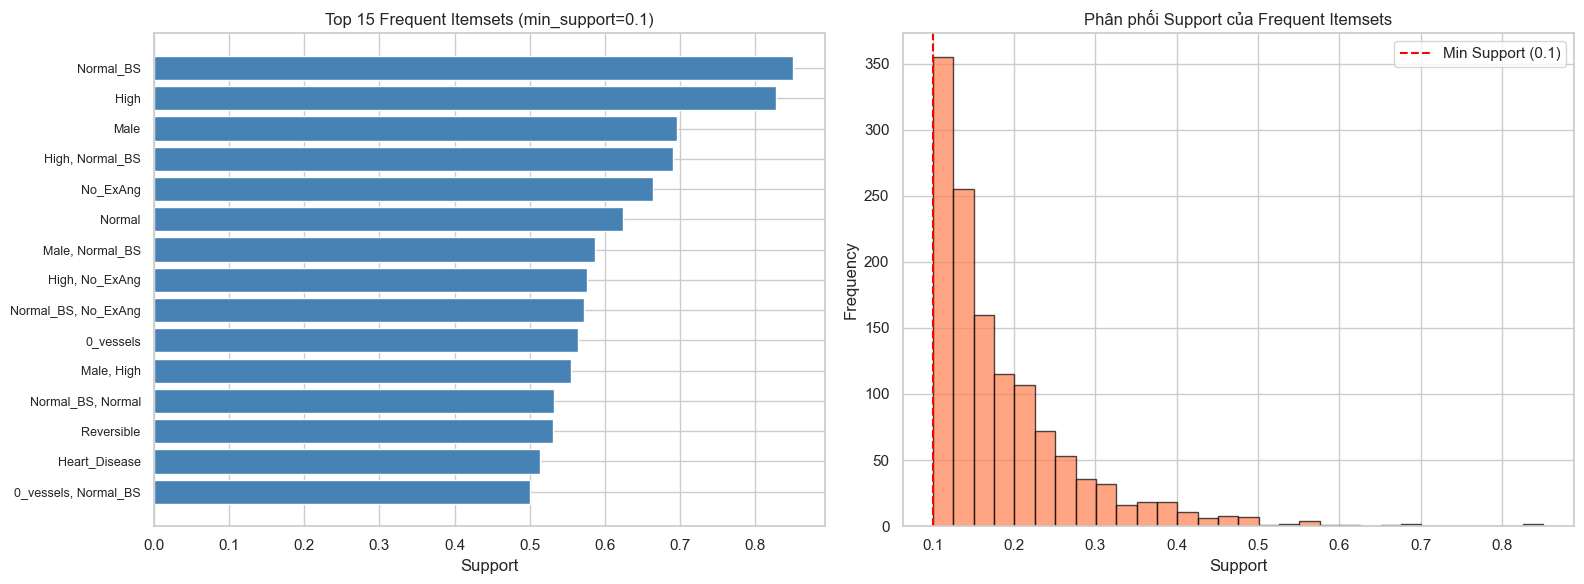

In [10]:
# Tìm frequent itemsets với Apriori
min_support = 0.1  # Minimum support threshold (10%)
frequent_itemsets = apriori(df_encoded, min_support=min_support, use_colnames=True, max_len=3)

print(f"Số lượng frequent itemsets: {len(frequent_itemsets)}")
print(f"\nTop 10 frequent itemsets:")
display(frequent_itemsets.sort_values('support', ascending=False).head(10))

# Visualize support của frequent itemsets
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot cho top itemsets
top_itemsets = frequent_itemsets.sort_values('support', ascending=False).head(15)
top_itemsets['itemset_str'] = top_itemsets['itemsets'].apply(lambda x: ', '.join(list(x)))
axes[0].barh(range(len(top_itemsets)), top_itemsets['support'], color='steelblue')
axes[0].set_yticks(range(len(top_itemsets)))
axes[0].set_yticklabels(top_itemsets['itemset_str'], fontsize=9)
axes[0].set_xlabel('Support')
axes[0].set_title(f'Top 15 Frequent Itemsets (min_support={min_support})')
axes[0].invert_yaxis()

# Distribution của support
axes[1].hist(frequent_itemsets['support'], bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Support')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Phân phối Support của Frequent Itemsets')
axes[1].axvline(min_support, color='red', linestyle='--', label=f'Min Support ({min_support})')
axes[1].legend()

plt.tight_layout()
plt.show()


In [17]:
# Tạo Association Rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

# Tính toán thêm các metrics
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))
rules['rule'] = rules['antecedents_str'] + ' => ' + rules['consequents_str']

# CHỈ LẤY CÁC RULES CÓ TARGET (Heart_Disease hoặc No_Disease) LÀM CONSEQUENT
# Điều này làm cho rules có ý nghĩa cho phân loại bệnh
rules['has_target'] = rules['consequents'].apply(
    lambda x: any('Heart_Disease' in str(item) or 'No_Disease' in str(item) for item in x)
)
rules_for_classification = rules[rules['has_target']].copy()

print(f"Số lượng association rules tổng cộng: {len(rules)}")
print(f"Số lượng rules liên quan đến phân loại bệnh (có target trong consequent): {len(rules_for_classification)}")

print(f"\nTop 10 rules theo Support (giảm dần) - CHỈ RULES PHÂN LOẠI BỆNH:")
display(rules_for_classification[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']]
        .sort_values('support', ascending=False).head(10))

# CHỈ áp dụng cho rules phân loại bệnh
strong_rules = rules_for_classification[
    (rules_for_classification['support'] > 0.4) & 
    (rules_for_classification['confidence'] > 0.5)
].copy()
print(f"\nSố lượng rules hợp lệ cho phân loại (support > 0.4 và confidence > 0.5): {len(strong_rules)}")

if len(strong_rules) > 0:
    # Tạo composite score kết hợp support và confidence
    # Score = support * confidence (cân bằng cả hai yếu tố)
    strong_rules['composite_score'] = strong_rules['support'] * strong_rules['confidence']
    
    print(f"\nTop 5 rules mạnh nhất cho phân loại bệnh (theo composite score = support × confidence):")
    top_rules = strong_rules.sort_values('composite_score', ascending=False).head(5)
    display(top_rules[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift', 'composite_score']])
    

Số lượng association rules tổng cộng: 2545
Số lượng rules liên quan đến phân loại bệnh (có target trong consequent): 314

Top 10 rules theo Support (giảm dần) - CHỈ RULES PHÂN LOẠI BỆNH:


,antecedents_str,consequents_str,support,confidence,lift
140,Normal_BS,Heart_Disease,0.443902,0.521789,1.016794
135,No_ExAng,Heart_Disease,0.443902,0.669118,1.303889
130,High,Heart_Disease,0.440000,0.531840,1.036379
7,0_vessels,Heart_Disease,0.404878,0.717993,1.399131
178,Male,No_Disease,0.402927,0.579243,1.189827
142,Reversible,Heart_Disease,0.401951,0.757353,1.475830
1600,"High, No_ExAng",Heart_Disease,0.386341,0.671186,1.307920
1602,No_ExAng,"Heart_Disease, High",0.386341,0.582353,1.323529
1671,"Normal_BS, No_ExAng",Heart_Disease,0.380488,0.664395,1.294687
1673,No_ExAng,"Heart_Disease, Normal_BS",0.380488,0.573529,1.292017



Số lượng rules hợp lệ cho phân loại (support > 0.4 và confidence > 0.5): 6

Top 5 rules mạnh nhất cho phân loại bệnh (theo composite score = support × confidence):


,antecedents_str,consequents_str,support,confidence,lift,composite_score
142,Reversible,Heart_Disease,0.401951,0.757353,1.475830,0.304419
135,No_ExAng,Heart_Disease,0.443902,0.669118,1.303889,0.297023
7,0_vessels,Heart_Disease,0.404878,0.717993,1.399131,0.290700
130,High,Heart_Disease,0.440000,0.531840,1.036379,0.234009
178,Male,No_Disease,0.402927,0.579243,1.189827,0.233392


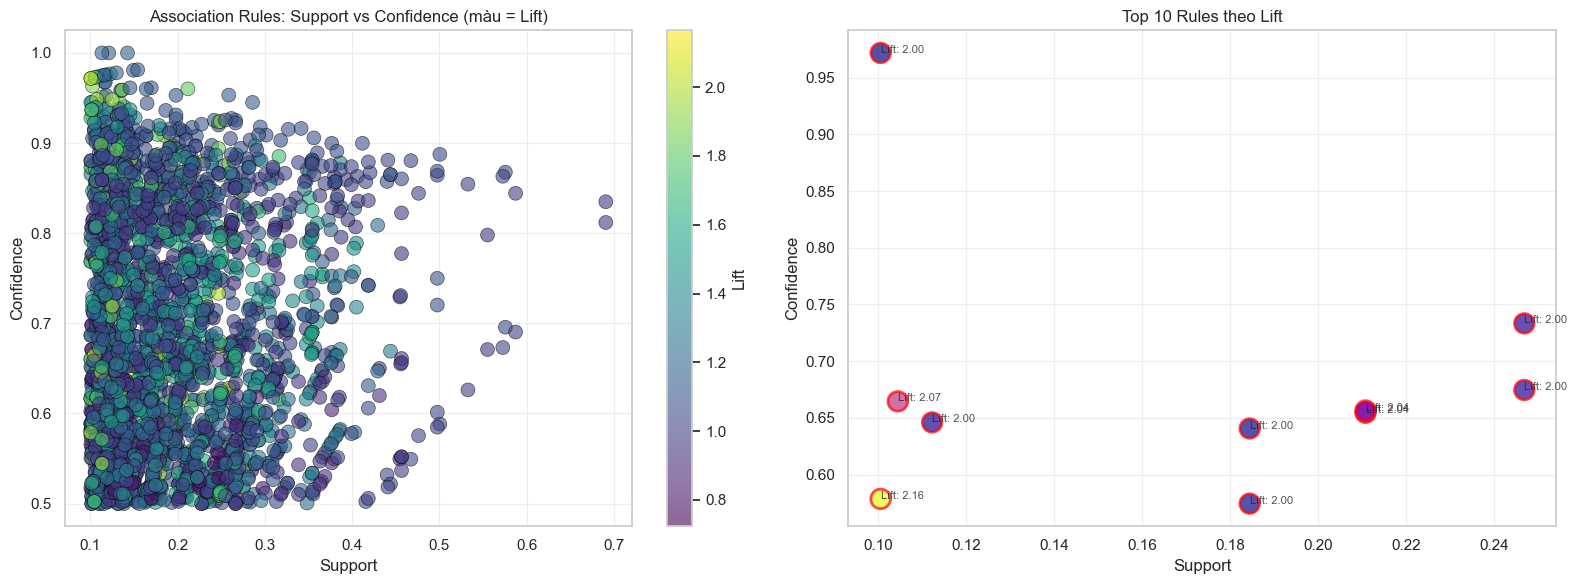

In [18]:
# Visualization 1: Scatter plot Confidence vs Support (màu theo Lift)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(rules['support'], rules['confidence'], 
                           c=rules['lift'], cmap='viridis', 
                           s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confidence')
axes[0].set_title('Association Rules: Support vs Confidence (màu = Lift)')
plt.colorbar(scatter1, ax=axes[0], label='Lift')
axes[0].grid(True, alpha=0.3)

# Top rules theo lift
top_rules = rules.nlargest(10, 'lift')
axes[1].scatter(top_rules['support'], top_rules['confidence'], 
               s=200, alpha=0.7, c=top_rules['lift'], cmap='plasma',
               edgecolors='red', linewidth=2)
for idx, row in top_rules.iterrows():
    axes[1].annotate(f"Lift: {row['lift']:.2f}", 
                     (row['support'], row['confidence']),
                     fontsize=8, alpha=0.8)
axes[1].set_xlabel('Support')
axes[1].set_ylabel('Confidence')
axes[1].set_title('Top 10 Rules theo Lift')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


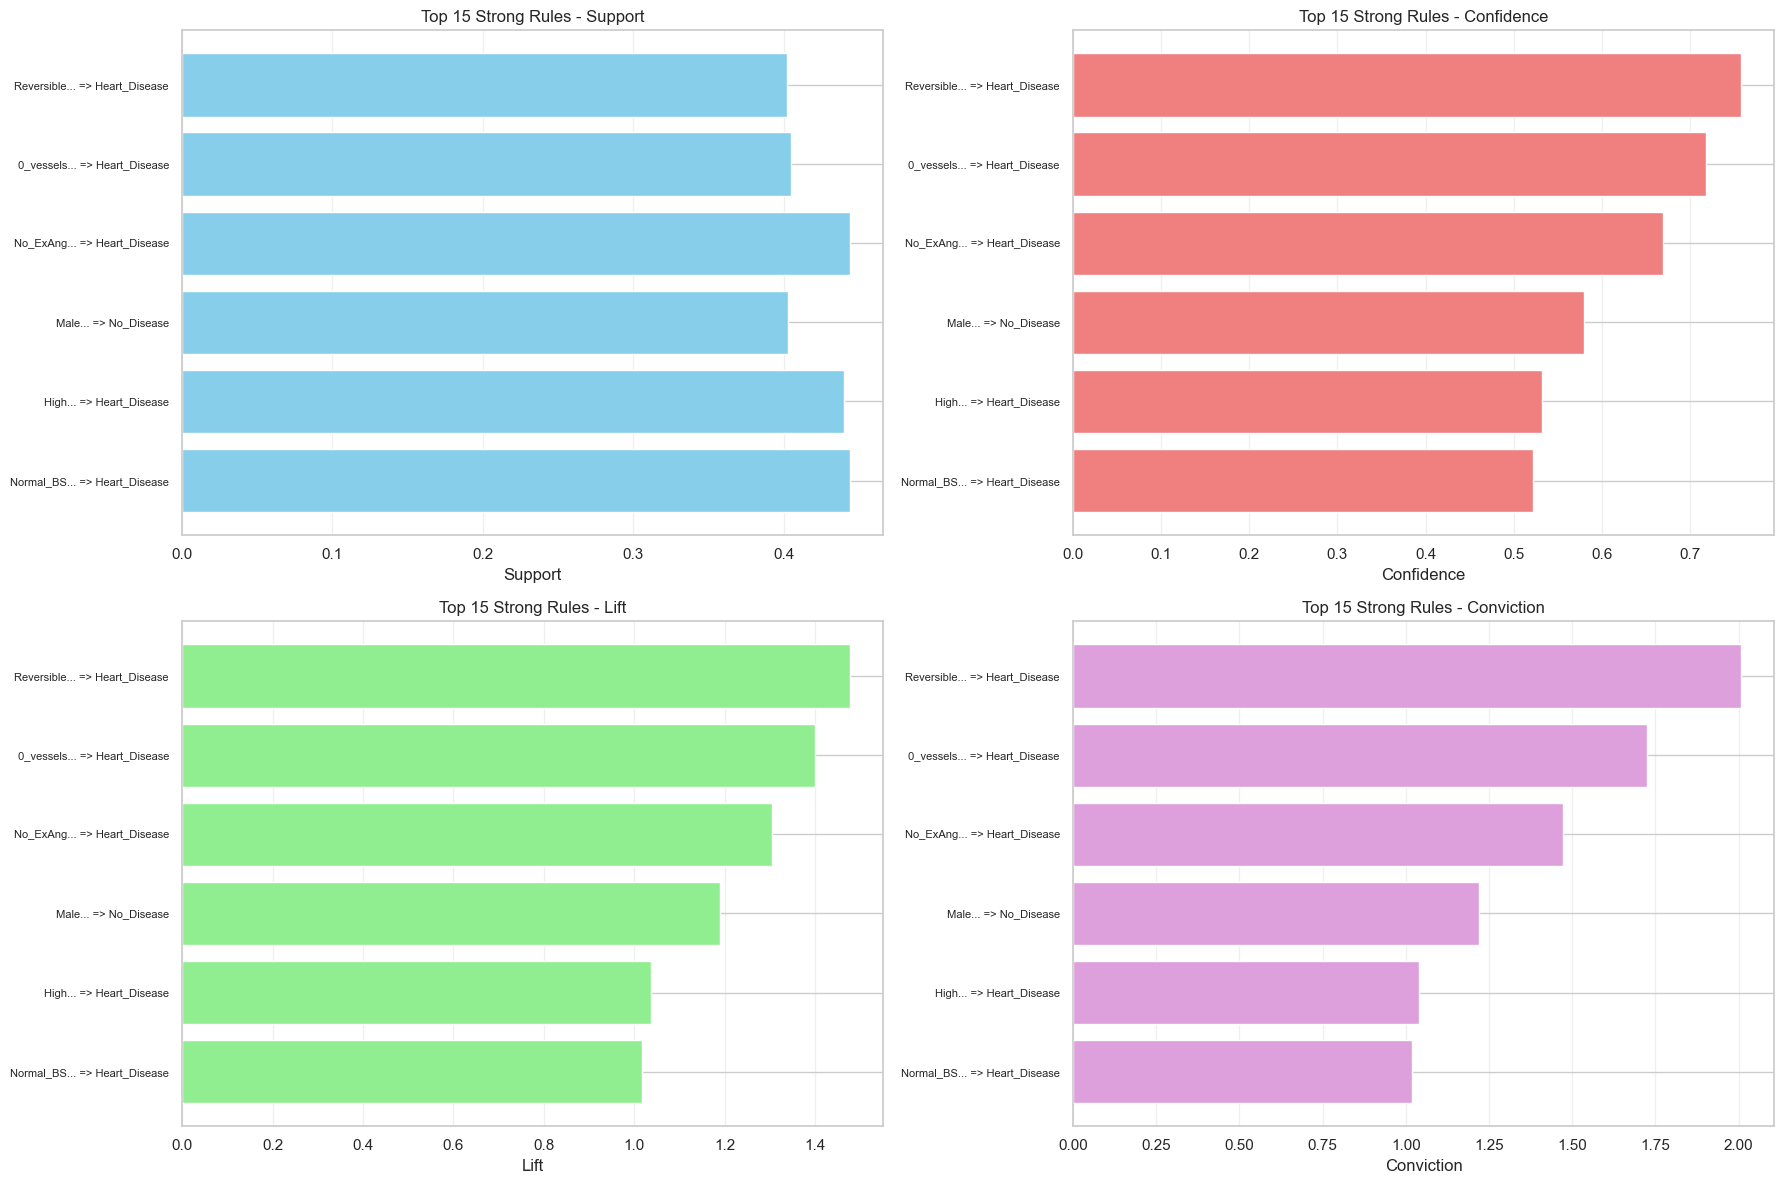

In [20]:
# Visualization 2: Bar charts cho các metrics
if len(strong_rules) > 0:
    top_strong = strong_rules.nlargest(15, 'lift')
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # Support
    axes[0, 0].barh(range(len(top_strong)), top_strong['support'], color='skyblue')
    axes[0, 0].set_yticks(range(len(top_strong)))
    axes[0, 0].set_yticklabels([f"{row['antecedents_str'][:30]}... => {row['consequents_str']}" 
                                 for _, row in top_strong.iterrows()], fontsize=8)
    axes[0, 0].set_xlabel('Support')
    axes[0, 0].set_title('Top 15 Strong Rules - Support')
    axes[0, 0].invert_yaxis()
    axes[0, 0].grid(axis='x', alpha=0.3)
    
    # Confidence
    axes[0, 1].barh(range(len(top_strong)), top_strong['confidence'], color='lightcoral')
    axes[0, 1].set_yticks(range(len(top_strong)))
    axes[0, 1].set_yticklabels([f"{row['antecedents_str'][:30]}... => {row['consequents_str']}" 
                                 for _, row in top_strong.iterrows()], fontsize=8)
    axes[0, 1].set_xlabel('Confidence')
    axes[0, 1].set_title('Top 15 Strong Rules - Confidence')
    axes[0, 1].invert_yaxis()
    axes[0, 1].grid(axis='x', alpha=0.3)
    
    # Lift
    axes[1, 0].barh(range(len(top_strong)), top_strong['lift'], color='lightgreen')
    axes[1, 0].set_yticks(range(len(top_strong)))
    axes[1, 0].set_yticklabels([f"{row['antecedents_str'][:30]}... => {row['consequents_str']}" 
                                 for _, row in top_strong.iterrows()], fontsize=8)
    axes[1, 0].set_xlabel('Lift')
    axes[1, 0].set_title('Top 15 Strong Rules - Lift')
    axes[1, 0].invert_yaxis()
    axes[1, 0].grid(axis='x', alpha=0.3)
    
    # Conviction
    if 'conviction' in top_strong.columns:
        axes[1, 1].barh(range(len(top_strong)), top_strong['conviction'], color='plum')
        axes[1, 1].set_yticks(range(len(top_strong)))
        axes[1, 1].set_yticklabels([f"{row['antecedents_str'][:30]}... => {row['consequents_str']}" 
                                     for _, row in top_strong.iterrows()], fontsize=8)
        axes[1, 1].set_xlabel('Conviction')
        axes[1, 1].set_title('Top 15 Strong Rules - Conviction')
        axes[1, 1].invert_yaxis()
        axes[1, 1].grid(axis='x', alpha=0.3)
    else:
        axes[1, 1].axis('off')
        axes[1, 1].text(0.5, 0.5, 'Conviction metric not available', 
                        ha='center', va='center', fontsize=12)
    
    plt.tight_layout()
    plt.show()
else:
    print("Không có rules nào thỏa mãn điều kiện (support > 0.05 và confidence > 0.8)")


In [ ]:
# Import thư viện cho Association Rules
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Tạo bản sao dữ liệu để discretize
apriori_df = raw_df.copy()

# Discretize các biến số liên tục thành categories
# Age: chia thành nhóm tuổi
apriori_df['age_group'] = pd.cut(apriori_df['age'], 
                                  bins=[0, 45, 55, 65, 100], 
                                  labels=['Young', 'Middle', 'Senior', 'Elderly'])

# Trestbps (huyết áp nghỉ): chia thành nhóm
apriori_df['trestbps_group'] = pd.cut(apriori_df['trestbps'],
                                       bins=[0, 120, 140, 200],
                                       labels=['Normal', 'Elevated', 'High'])

# Chol (cholesterol): chia thành nhóm
apriori_df['chol_group'] = pd.cut(apriori_df['chol'],
                                   bins=[0, 200, 240, 600],
                                   labels=['Normal', 'Borderline', 'High'])

# Thalach (nhịp tim tối đa): chia thành nhóm
apriori_df['thalach_group'] = pd.cut(apriori_df['thalach'],
                                      bins=[0, 120, 150, 250],
                                      labels=['Low', 'Normal', 'High'])

# Oldpeak: chia thành nhóm
apriori_df['oldpeak_group'] = pd.cut(apriori_df['oldpeak'],
                                      bins=[-1, 0, 1, 2, 10],
                                      labels=['None', 'Mild', 'Moderate', 'Severe'])

# Chuyển đổi các biến categorical thành string format
apriori_df['sex_str'] = apriori_df['sex'].map({0: 'Female', 1: 'Male'})
apriori_df['cp_str'] = apriori_df['cp'].map({0: 'Typical', 1: 'Atypical', 2: 'Non-anginal', 3: 'Asymptomatic'})
apriori_df['fbs_str'] = apriori_df['fbs'].map({0: 'Normal_BS', 1: 'High_BS'})
apriori_df['restecg_str'] = apriori_df['restecg'].map({0: 'Normal_ECG', 1: 'ST-T_abnormal', 2: 'LVH'})
apriori_df['exang_str'] = apriori_df['exang'].map({0: 'No_ExAng', 1: 'ExAng'})
apriori_df['slope_str'] = apriori_df['slope'].map({0: 'Up', 1: 'Flat', 2: 'Down'})
apriori_df['ca_str'] = apriori_df['ca'].astype(str) + '_vessels'
apriori_df['thal_str'] = apriori_df['thal'].map({0: 'Normal', 1: 'Fixed', 2: 'Reversible', 3: 'Unknown'})
apriori_df['target_str'] = apriori_df['target'].map({0: 'No_Disease', 1: 'Heart_Disease'})

# Tạo transactions: mỗi hàng là một transaction với các items
transaction_data = []
for idx, row in apriori_df.iterrows():
    transaction = []
    transaction.append(row['age_group'])
    transaction.append(row['sex_str'])
    transaction.append(row['cp_str'])
    transaction.append(row['trestbps_group'])
    transaction.append(row['chol_group'])
    transaction.append(row['fbs_str'])
    transaction.append(row['restecg_str'])
    transaction.append(row['thalach_group'])
    transaction.append(row['exang_str'])
    transaction.append(row['oldpeak_group'])
    transaction.append(row['slope_str'])
    transaction.append(row['ca_str'])
    transaction.append(row['thal_str'])
    transaction.append(row['target_str'])
    # Loại bỏ NaN values
    transaction = [str(item) for item in transaction if pd.notna(item)]
    transaction_data.append(transaction)

# Encode transactions thành one-hot format
te = TransactionEncoder()
te_ary = te.fit(transaction_data).transform(transaction_data)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Số lượng transactions: {len(transaction_data)}")
print(f"Số lượng items: {len(te.columns_)}")
print(f"\nMột số items phổ biến:")
print(df_encoded.sum().sort_values(ascending=False).head(10))

#--------------------
# Tìm frequent itemsets với Apriori
min_support = 0.1  # Minimum support threshold (10%)
frequent_itemsets = apriori(df_encoded, min_support=min_support, use_colnames=True, max_len=3)

print(f"Số lượng frequent itemsets: {len(frequent_itemsets)}")
print(f"\nTop 10 frequent itemsets:")
display(frequent_itemsets.sort_values('support', ascending=False).head(10))

# Visualize support của frequent itemsets
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot cho top itemsets
top_itemsets = frequent_itemsets.sort_values('support', ascending=False).head(15)
top_itemsets['itemset_str'] = top_itemsets['itemsets'].apply(lambda x: ', '.join(list(x)))
axes[0].barh(range(len(top_itemsets)), top_itemsets['support'], color='steelblue')
axes[0].set_yticks(range(len(top_itemsets)))
axes[0].set_yticklabels(top_itemsets['itemset_str'], fontsize=9)
axes[0].set_xlabel('Support')
axes[0].set_title(f'Top 15 Frequent Itemsets (min_support={min_support})')
axes[0].invert_yaxis()

# Distribution của support
axes[1].hist(frequent_itemsets['support'], bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Support')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Phân phối Support của Frequent Itemsets')
axes[1].axvline(min_support, color='red', linestyle='--', label=f'Min Support ({min_support})')
axes[1].legend()

plt.tight_layout()
plt.show()

#-----------------------------------
# Tạo Association Rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

# Tính toán thêm các metrics
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))
rules['rule'] = rules['antecedents_str'] + ' => ' + rules['consequents_str']

# CHỈ LẤY CÁC RULES CÓ TARGET (Heart_Disease hoặc No_Disease) LÀM CONSEQUENT
# Điều này làm cho rules có ý nghĩa cho phân loại bệnh
rules['has_target'] = rules['consequents'].apply(
    lambda x: any('Heart_Disease' in str(item) or 'No_Disease' in str(item) for item in x)
)
rules_for_classification = rules[rules['has_target']].copy()

print(f"Số lượng association rules tổng cộng: {len(rules)}")
print(f"Số lượng rules liên quan đến phân loại bệnh (có target trong consequent): {len(rules_for_classification)}")

print(f"\nTop 10 rules theo Support (giảm dần) - CHỈ RULES PHÂN LOẠI BỆNH:")
display(rules_for_classification[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']]
        .sort_values('support', ascending=False).head(10))

# CHỈ áp dụng cho rules phân loại bệnh
strong_rules = rules_for_classification[
    (rules_for_classification['support'] > 0.4) & 
    (rules_for_classification['confidence'] > 0.5)
].copy()
print(f"\nSố lượng rules hợp lệ cho phân loại (support > 0.4 và confidence > 0.5): {len(strong_rules)}")

if len(strong_rules) > 0:
    # Tạo composite score kết hợp support và confidence
    # Score = support * confidence (cân bằng cả hai yếu tố)
    strong_rules['composite_score'] = strong_rules['support'] * strong_rules['confidence']
    
    print(f"\nTop 5 rules mạnh nhất cho phân loại bệnh (theo composite score = support × confidence):")
    top_rules = strong_rules.sort_values('composite_score', ascending=False).head(5)
    display(top_rules[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift', 'composite_score']])
    
#--------------------------------
# Visualization 1: Scatter plot Confidence vs Support (màu theo Lift)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(rules['support'], rules['confidence'], 
                           c=rules['lift'], cmap='viridis', 
                           s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confidence')
axes[0].set_title('Association Rules: Support vs Confidence (màu = Lift)')
plt.colorbar(scatter1, ax=axes[0], label='Lift')
axes[0].grid(True, alpha=0.3)

# Top rules theo lift
top_rules = rules.nlargest(10, 'lift')
axes[1].scatter(top_rules['support'], top_rules['confidence'], 
               s=200, alpha=0.7, c=top_rules['lift'], cmap='plasma',
               edgecolors='red', linewidth=2)
for idx, row in top_rules.iterrows():
    axes[1].annotate(f"Lift: {row['lift']:.2f}", 
                     (row['support'], row['confidence']),
                     fontsize=8, alpha=0.8)
axes[1].set_xlabel('Support')
axes[1].set_ylabel('Confidence')
axes[1].set_title('Top 10 Rules theo Lift')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#--------------------------------
# Visualization 2: Bar charts cho các metrics
if len(strong_rules) > 0:
    top_strong = strong_rules.nlargest(15, 'lift')
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # Support
    axes[0, 0].barh(range(len(top_strong)), top_strong['support'], color='skyblue')
    axes[0, 0].set_yticks(range(len(top_strong)))
    axes[0, 0].set_yticklabels([f"{row['antecedents_str'][:30]}... => {row['consequents_str']}" 
                                 for _, row in top_strong.iterrows()], fontsize=8)
    axes[0, 0].set_xlabel('Support')
    axes[0, 0].set_title('Top 15 Strong Rules - Support')
    axes[0, 0].invert_yaxis()
    axes[0, 0].grid(axis='x', alpha=0.3)
    
    # Confidence
    axes[0, 1].barh(range(len(top_strong)), top_strong['confidence'], color='lightcoral')
    axes[0, 1].set_yticks(range(len(top_strong)))
    axes[0, 1].set_yticklabels([f"{row['antecedents_str'][:30]}... => {row['consequents_str']}" 
                                 for _, row in top_strong.iterrows()], fontsize=8)
    axes[0, 1].set_xlabel('Confidence')
    axes[0, 1].set_title('Top 15 Strong Rules - Confidence')
    axes[0, 1].invert_yaxis()
    axes[0, 1].grid(axis='x', alpha=0.3)
    
    # Lift
    axes[1, 0].barh(range(len(top_strong)), top_strong['lift'], color='lightgreen')
    axes[1, 0].set_yticks(range(len(top_strong)))
    axes[1, 0].set_yticklabels([f"{row['antecedents_str'][:30]}... => {row['consequents_str']}" 
                                 for _, row in top_strong.iterrows()], fontsize=8)
    axes[1, 0].set_xlabel('Lift')
    axes[1, 0].set_title('Top 15 Strong Rules - Lift')
    axes[1, 0].invert_yaxis()
    axes[1, 0].grid(axis='x', alpha=0.3)
    
    # Conviction
    if 'conviction' in top_strong.columns:
        axes[1, 1].barh(range(len(top_strong)), top_strong['conviction'], color='plum')
        axes[1, 1].set_yticks(range(len(top_strong)))
        axes[1, 1].set_yticklabels([f"{row['antecedents_str'][:30]}... => {row['consequents_str']}" 
                                     for _, row in top_strong.iterrows()], fontsize=8)
        axes[1, 1].set_xlabel('Conviction')
        axes[1, 1].set_title('Top 15 Strong Rules - Conviction')
        axes[1, 1].invert_yaxis()
        axes[1, 1].grid(axis='x', alpha=0.3)
    else:
        axes[1, 1].axis('off')
        axes[1, 1].text(0.5, 0.5, 'Conviction metric not available', 
                        ha='center', va='center', fontsize=12)
    
    plt.tight_layout()
    plt.show()
else:
    print("Không có rules nào thỏa mãn điều kiện (support > 0.05 và confidence > 0.8)")
